In [8]:
import numpy
import pandas

from matplotlib import pyplot
import seaborn

estres_empleados = pandas.read_csv(
    "../../conjuntos/estres.csv"
)

estres_empleados

,CARGA,SALARIO,ESTRES
0,10,18205.19,0.77
1,7,16133.27,0.13
2,8,15754.10,0.86
3,14,12583.51,2.05
4,9,14025.50,1.06
...,...,...,...
995,5,14347.02,0.48
996,13,21470.59,1.14
997,11,11801.91,1.04
998,14,21902.42,0.10


In [9]:
estres_empleados[["CARGA", "ESTRES"]].groupby("CARGA").mean()

,ESTRES
CARGA,
0,0.250000
1,0.134444
2,0.076000
3,0.438947
4,0.525000
5,0.352353
6,0.627000
7,0.565844
8,0.861406


<Axes: xlabel='CARGA'>

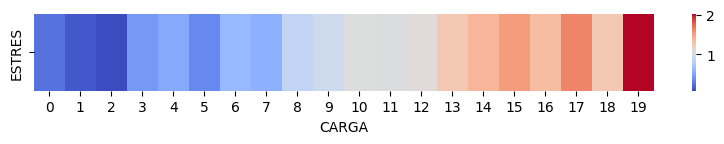

In [20]:
figure, axis = pyplot.subplots(1, 1, figsize=(10, 1))

seaborn.heatmap(
    estres_empleados[
        ["CARGA", "ESTRES"]
    ].groupby("CARGA").mean().T,
    cmap="coolwarm"
)

<Axes: xlabel='SALARIO_Q'>

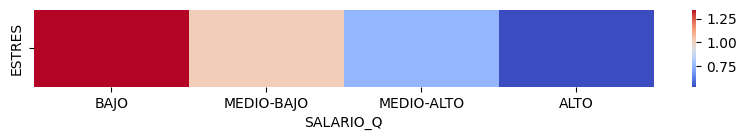

In [22]:
figure, axis = pyplot.subplots(1, 1, figsize=(10, 1))

estres_empleados["SALARIO_Q"] = pandas.qcut(
    estres_empleados["SALARIO"], 
    q=(0, 0.25, 0.5, 0.75, 1),
    labels=("BAJO", "MEDIO-BAJO", "MEDIO-ALTO", "ALTO")
)

seaborn.heatmap(
    estres_empleados[
        ["SALARIO_Q", "ESTRES"]
    ].groupby(
        "SALARIO_Q",
        observed=False
    ).mean().T,
    cmap="coolwarm"
)

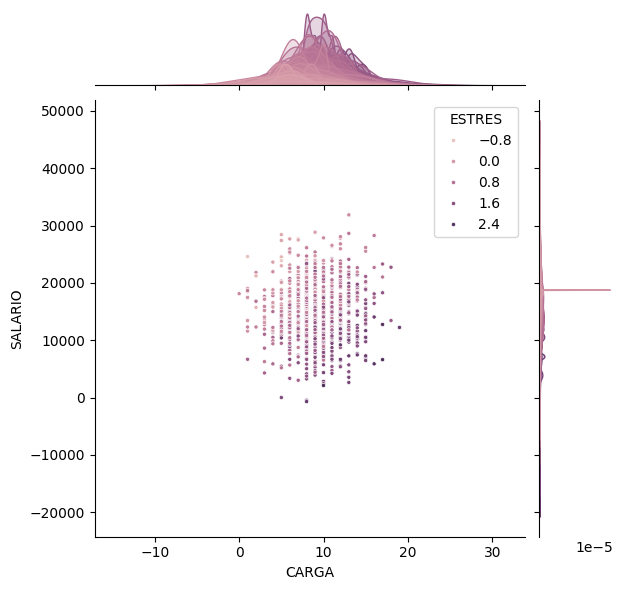

In [31]:
seaborn.jointplot(
    estres_empleados, 
    x="CARGA", 
    y="SALARIO", 
    hue="ESTRES", 
    marker=".",
)

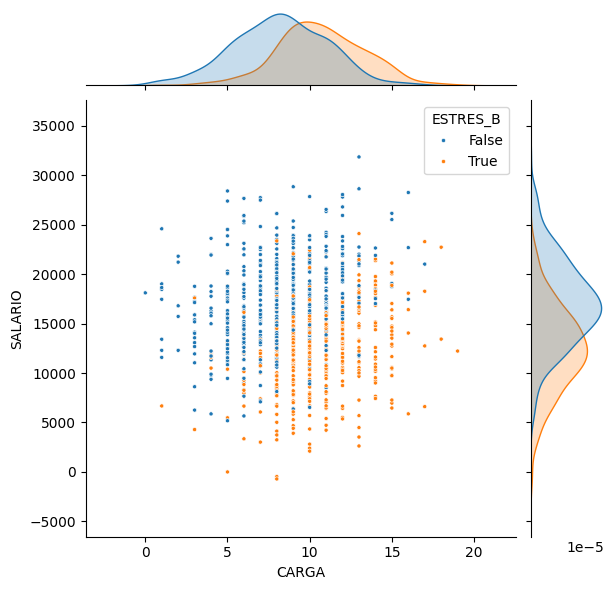

In [36]:
estres_empleados["ESTRES_B"] = estres_empleados["ESTRES"] >= 1

seaborn.jointplot(
    estres_empleados, 
    x="CARGA", 
    y="SALARIO", 
    hue="ESTRES_B", 
    marker=".",
)

In [37]:
X = estres_empleados[["CARGA", "SALARIO"]]

X

,CARGA,SALARIO
0,10,18205.19
1,7,16133.27
2,8,15754.10
3,14,12583.51
4,9,14025.50
...,...,...
995,5,14347.02
996,13,21470.59
997,11,11801.91
998,14,21902.42


In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X)

Xs = scaler.transform(X)

pandas.DataFrame(
    Xs,
    columns=("CARGA_S", "SALARIO_S")
)

,CARGA_S,SALARIO_S
0,0.236014,0.635985
1,-0.754254,0.218275
2,-0.424165,0.141832
3,1.556371,-0.497375
4,-0.094075,-0.206662
...,...,...
995,-1.414432,-0.141842
996,1.226281,1.294307
997,0.566103,-0.654950
998,1.556371,1.381366


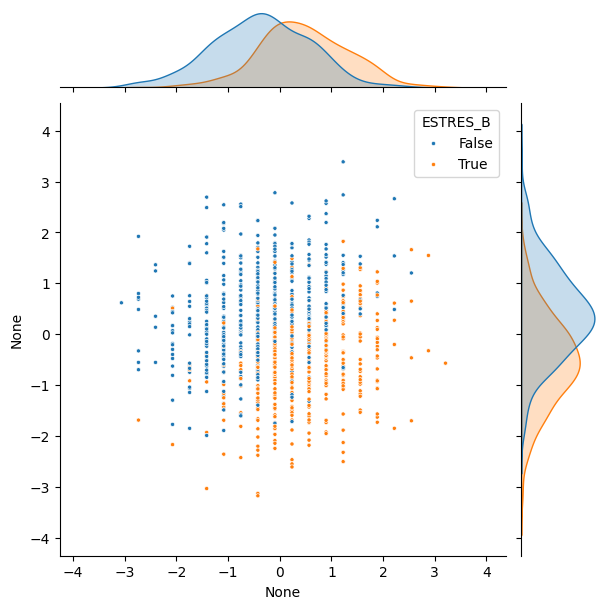

In [43]:
seaborn.jointplot(
    x=Xs[:, 0], 
    y=Xs[:, 1], 
    hue=estres_empleados["ESTRES_B"], 
    marker=".",
)

In [45]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

scaler.fit(X)

Xs = scaler.transform(X)

pandas.DataFrame(
    Xs,
    columns=("CARGA_S", "SALARIO_S")
)

,CARGA_S,SALARIO_S
0,0.25,0.488505
1,-0.50,0.169744
2,-0.25,0.111410
3,1.25,-0.376379
4,0.00,-0.154532
...,...,...
995,-1.00,-0.105067
996,1.00,0.990880
997,0.50,-0.496626
998,1.25,1.057316


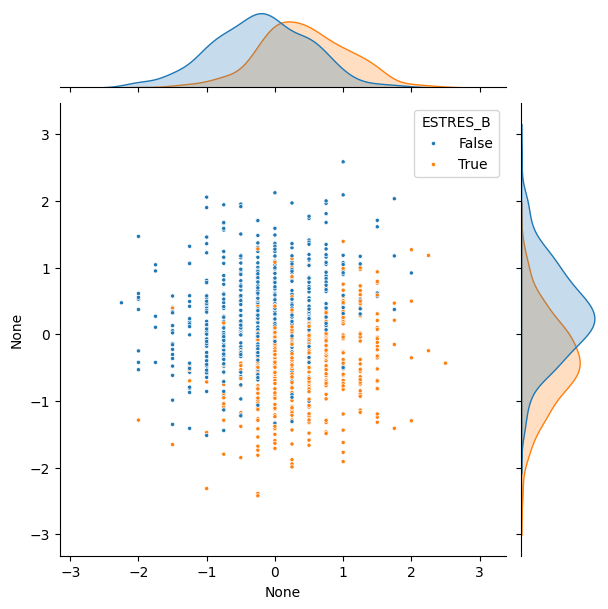

In [46]:
seaborn.jointplot(
    x=Xs[:, 0], 
    y=Xs[:, 1], 
    hue=estres_empleados["ESTRES_B"], 
    marker=".",
)

In [56]:
from sklearn.decomposition import PCA

pca = PCA()

pca.fit(Xs)

Xc = pca.transform(Xs)

pandas.DataFrame(
    Xc,
    columns=("C1", "C2")
)

,C1,C2
0,0.502348,-0.123058
1,-0.181184,-0.566784
2,-0.089816,-0.326878
3,0.344141,1.189571
4,-0.170596,0.029071
...,...,...
995,-0.688534,-0.827777
996,1.338132,0.218037
997,-0.174783,0.634885
998,1.532959,0.388202


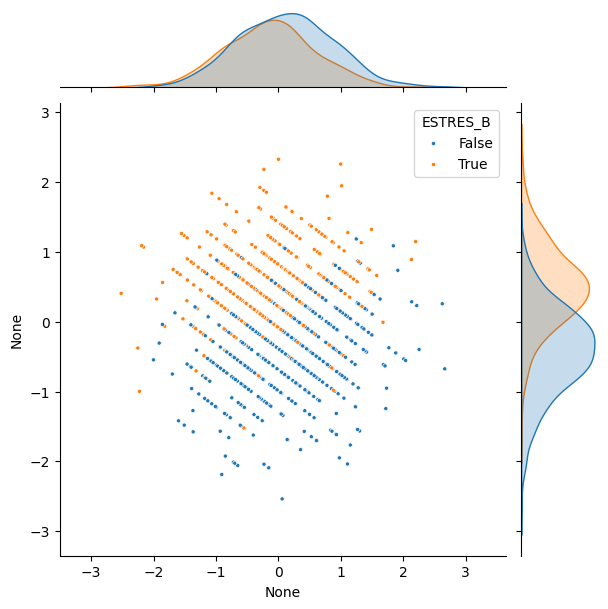

In [58]:
seaborn.jointplot(
    x=Xc[:, 0], 
    y=Xc[:, 1], 
    hue=estres_empleados["ESTRES_B"], 
    marker=".",
)

In [61]:
X = estres_empleados[["CARGA", "SALARIO"]].values

X

array([[1.000000e+01, 1.820519e+04],
       [7.000000e+00, 1.613327e+04],
       [8.000000e+00, 1.575410e+04],
       ...,
       [1.100000e+01, 1.180191e+04],
       [1.400000e+01, 2.190242e+04],
       [1.000000e+01, 1.273774e+04]])

In [63]:
y = estres_empleados["ESTRES"]

y

0      0.77
1      0.13
2      0.86
3      2.05
4      1.06
       ... 
995    0.48
996    1.14
997    1.04
998    0.10
999    1.16
Name: ESTRES, Length: 1000, dtype: float64

In [65]:
print("X", X.shape)
print("y", y.shape)

X (1000, 2)
y (1000,)


In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=800
)

print("X_train", X_train.shape)
print("X_test", X_train.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (800, 2)
X_test (800, 2)
y_train (800,)
y_test (200,)


<Axes: >

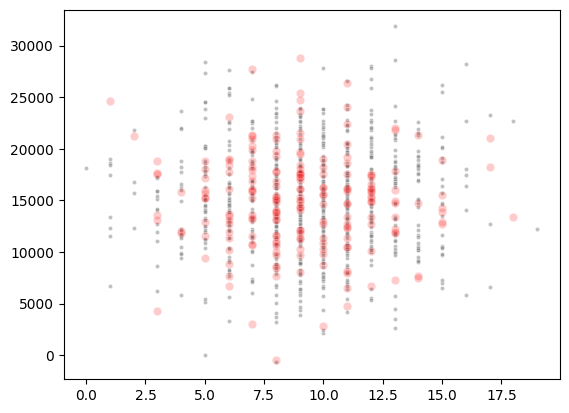

In [85]:
seaborn.scatterplot(
    x=X_train[:, 0], 
    y=X_train[:, 1], 
    marker=".", 
    alpha=0.5,
    color="gray"
)
seaborn.scatterplot(
    x=X_test[:, 0], 
    y=X_test[:, 1], 
    marker="o", 
    alpha=0.2,
    color="red"
)

<Axes: ylabel='ESTRES'>

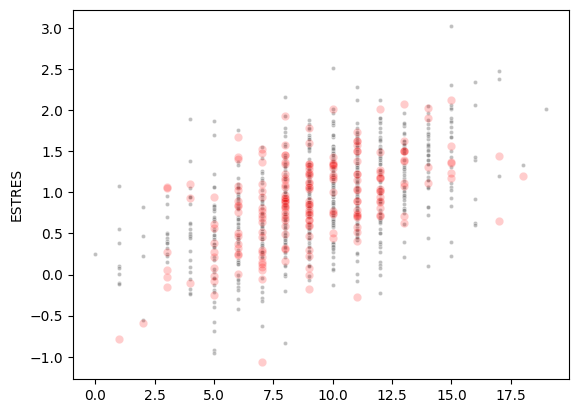

In [89]:
seaborn.scatterplot(
    x=X_train[:, 0], 
    y=y_train, 
    marker=".", 
    alpha=0.5,
    color="gray"
)
seaborn.scatterplot(
    x=X_test[:, 0], 
    y=y_test, 
    marker="o", 
    alpha=0.2,
    color="red"
)

<Axes: ylabel='ESTRES'>

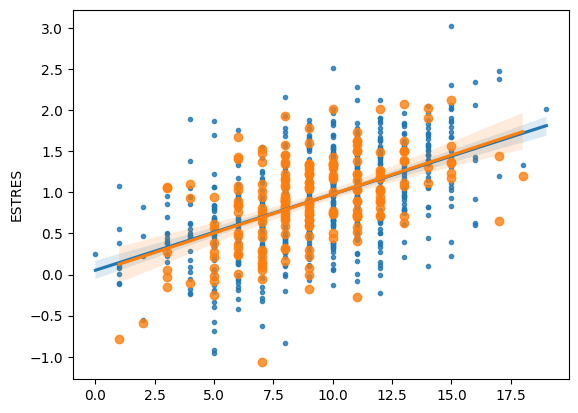

In [97]:
seaborn.regplot(
    x=X_train[:, 0],
    y=y_train,
    marker="."
)
seaborn.regplot(
    x=X_test[:, 0],
    y=y_test,
)

<Axes: ylabel='ESTRES'>

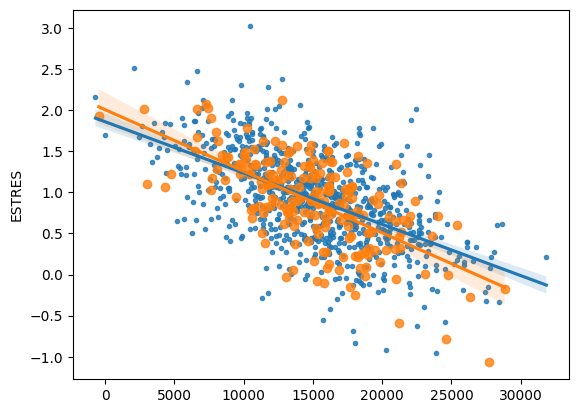

In [98]:
seaborn.regplot(
    x=X_train[:, 1],
    y=y_train,
    marker="."
)
seaborn.regplot(
    x=X_test[:, 1],
    y=y_test,
)